In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning.pruning_CSSP import *
from Pruning.pruning_filter import *
from Pruning.magnitude_pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random
from model import *
import contextlib
import io
import importlib

# Transform to tensor
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Files already downloaded and verified


/Users/yuekai/miniconda3/envs/CSSP_NN_Pruning/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model3.parameters(), lr=0.01)

epoch = 200

for i in range(epoch):
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model3(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model3(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size

    if i % 10 == 0:            
        print("-------Epoch {}-------".format(i+1))
        print("Total loss in test set: {}".format(total_test_loss))
        print("Total accuracy in test set: {}".format(total_accuracy / len(test_data)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 184.4105184674263
Total accuracy in test set: 0.5813
-------Epoch 11-------
Total loss in test set: 76.93647207319736
Total accuracy in test set: 0.8338
-------Epoch 21-------
Total loss in test set: 64.60297405719757
Total accuracy in test set: 0.8629
-------Epoch 31-------
Total loss in test set: 64.93798661977053
Total accuracy in test set: 0.8756
-------Epoch 41-------
Total loss in test set: 84.63007509708405
Total accuracy in test set: 0.8532
-------Epoch 51-------
Total loss in test set: 70.99254707247019
Total accuracy in test set: 0.8803
-------Epoch 61-------
Total loss in test set: 76.85768574476242
Total accuracy in test set: 0.8805
-------Epoch 71-------
Total loss in test set: 81.64989392459393
Total accuracy in test set: 0.8803
-------Epoch 81-------
Total loss in test set: 79.59097568690777
Total accuracy in test set: 0.8834
-------Epoch 91-------
Total loss in test set: 69.56581218540668
Total accuracy in test set: 0.8977
-

In [ ]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

model3 = VGG16().to(device)

# load the parameters of the trained model
model3.load_state_dict(
    torch.load("saved model and data/model3.pth", map_location=device)
)

model3.to(device)
model3.eval()

batch_list = list(train_loader)
selected_batches = random.sample(batch_list, 8)  
X = torch.cat([batch[0] for batch in selected_batches], dim=0)
X = X.to(device)
base_acc, _, base_loss = evaluate_pruned_model(model3, test_loader)
print(base_acc, base_loss)

/var/folders/7f/6p6cnlkn3qn5qj3ll8df4lsh0000gn/T/ipykernel_23383/3189647092.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("saved model and data/model3.pth",

0.9113 0.4497527387142181


### Part I: CSSP-Based Methods vs. L1 Filter Pruning under FLOPs Constraints

-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.90
Current ratio: 0.8973, Accuracy: 0.8915, Current FLOPs ratio: 0.8973
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.80
Current ratio: 0.7983, Accuracy: 0.8897, Current FLOPs ratio: 0.7983
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.70
Current ratio: 0.6953, Accuracy: 0.8818, Current FLOPs ratio: 0.6953
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.60
Current ratio: 0.5982, Accuracy: 0.8685, Current FLOPs ratio: 0.5982
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.50
Current ratio: 0.4958, Accuracy: 0.8470, Current FLOPs ratio: 0.4958
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.40
Current ratio: 0.3974, Accuracy: 0.8172, Current FLOPs ratio: 0.3974
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.30
Current ratio: 0.2967, Accuracy: 0.7808, Current FLOPs ratio: 0.2967
-------Begin pruning-------
Method: StrongRRQR	Target r

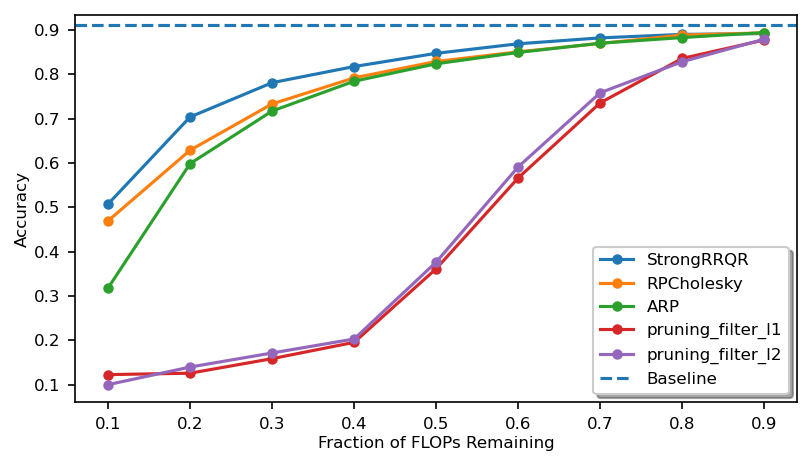

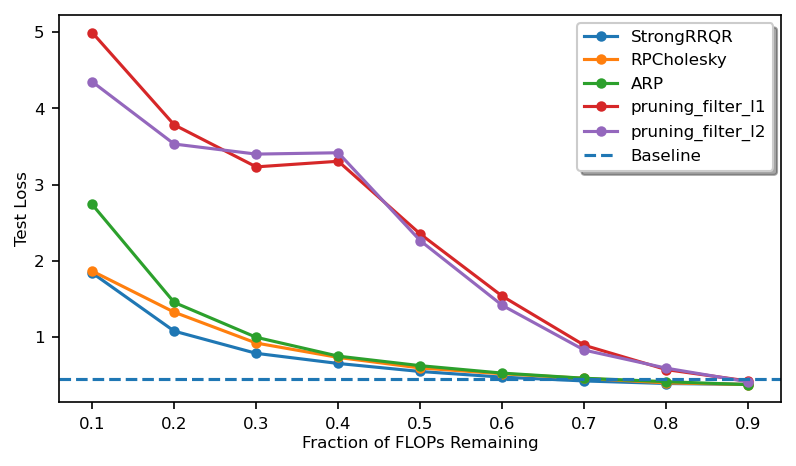

In [ ]:
methods_CSSP = ["StrongRRQR", "RPCholesky", "ARP"]


rho = np.linspace(0.9, 0.1, 9)
methods_flops = methods_CSSP + ["pruning_filter_l1", "pruning_filter_l2"]
all_accs = []
all_losses = []
layerwise_results = {}
pruned_models_dict = {}

# Run CSSP pruning methods
for method in methods_CSSP:
    accs = []
    model_CSSP, accs, losses, hist, pruned_models = iterative_pruning(copy.deepcopy(model3), X, (3, 32, 32), rho, 0.95, method, "flops", test_loader, train_loader)
    all_accs.append(accs)
    all_losses.append(losses)
    layerwise_results[method] = hist
    pruned_models_dict[method] = pruned_models

# Run pruning filter methods
filter_accs = []
filter_losses = []
for norm in ["l1", "l2"]:
    with contextlib.redirect_stdout(io.StringIO()):
        model_filter, filter_accs, filter_losses, filter_hist, filter_pruned_models = iterative_pruning_filter(
            model0=copy.deepcopy(model3),
            X=X,
            input_shape=(3, 32, 32),
            rho=rho,
            norm=norm,
            step_size=0.95,
            test_loader=test_loader,
            train_loader=train_loader
        )
    all_accs.append(filter_accs)
    all_losses.append(filter_losses)
    layerwise_results[f"pruning_filter_{norm}"] = filter_hist
    pruned_models_dict[f"pruning_filter_{norm}"] = filter_pruned_models

# Save pruning results
np.savez(
    "saved model and data/flops_vs_acc.npz",
    rho=rho,
    base_acc=base_acc,
    methods=np.array(methods_flops),
    all_accs=np.array(all_accs),
)

np.savez(
    "saved model and data/flops_vs_loss.npz",
    rho=rho,
    base_loss=base_loss,
    methods=np.array(methods_flops),
    all_losses=np.array(all_losses),
)

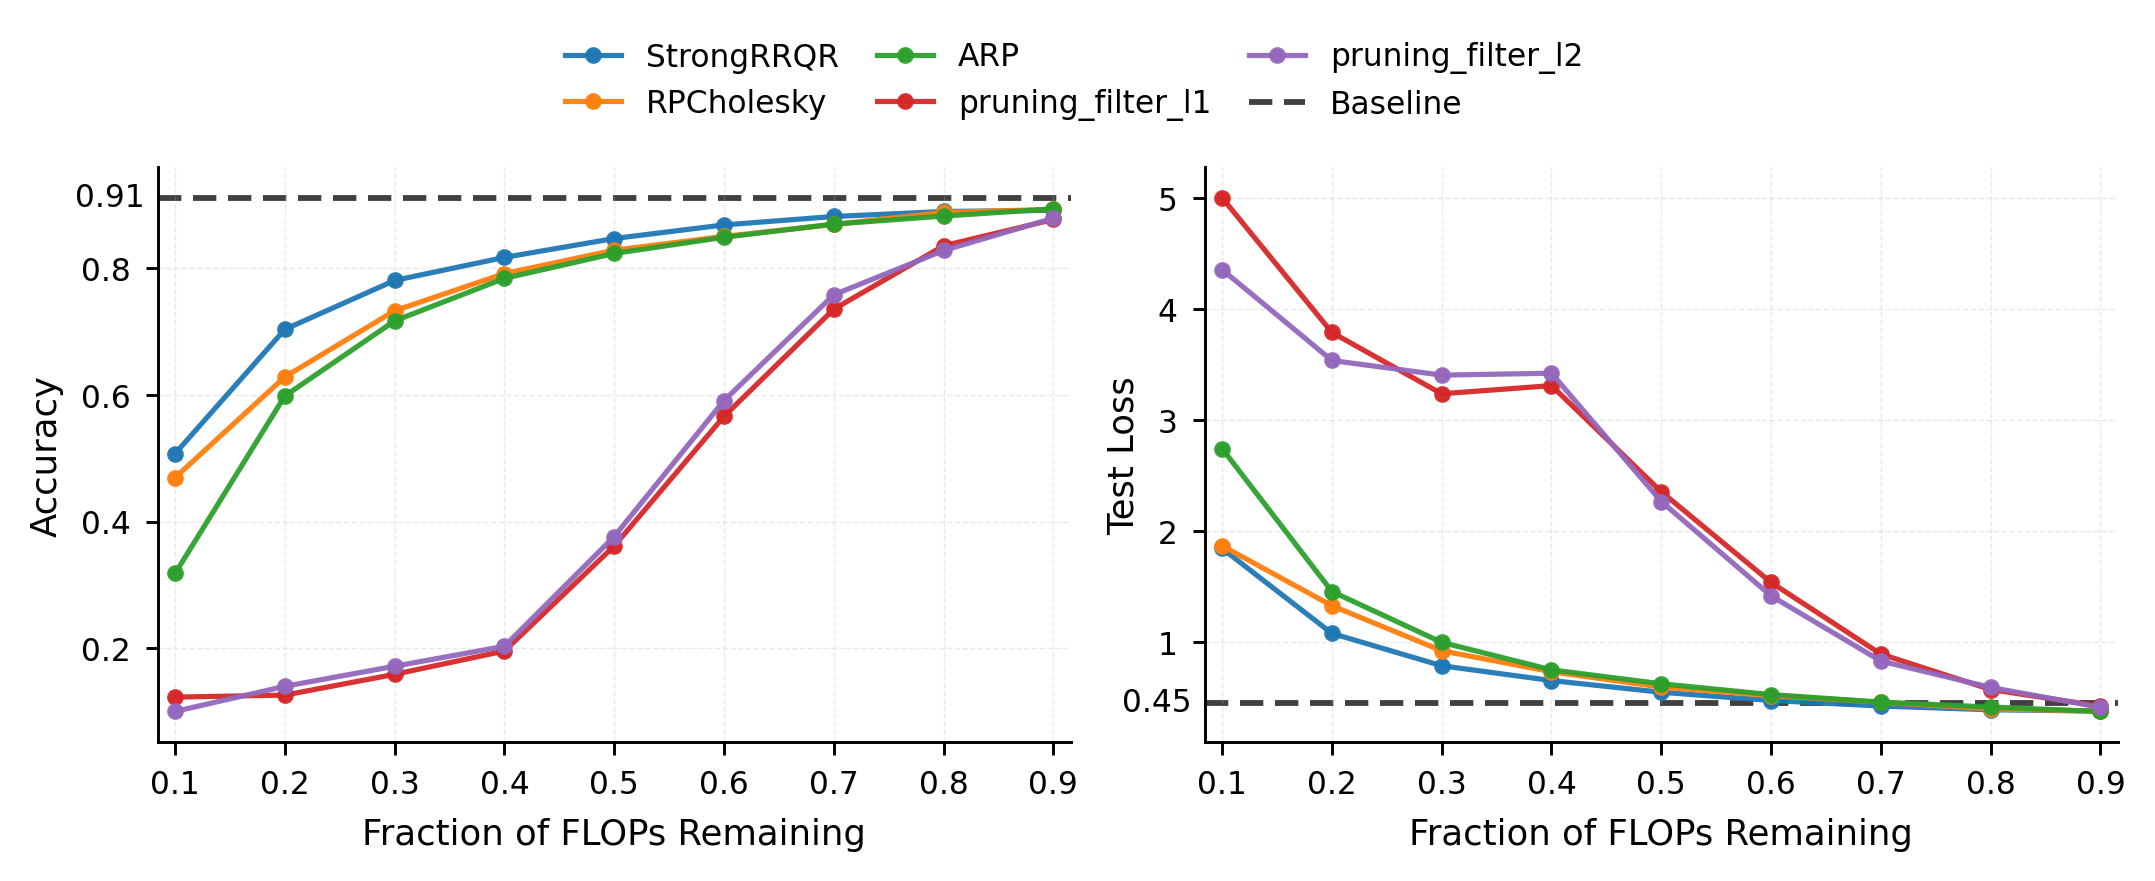

In [19]:
import importlib
import Plot as Plot
import Pruning.pruning_CSSP as pruning_CSSP

importlib.reload(Plot)
importlib.reload(pruning_CSSP)

# Plot pruning curves
Plot.plot_pruning_curve(
    base_acc,
    rho,
    all_accs,
    methods_flops,
    "flops",
    "Accuracy",
    title=None,
    base_loss=base_loss,
    losses=all_losses,
)

In [20]:
params = extract_params(model3.model)

for i, layer in enumerate(params):
    print(
        f"local_idx={i}, "
        f"layer_type={layer['layer_type']}, "
        f"global_idx={layer['layer_idx']}"
    )

local_idx=0, layer_type=ConvBNReLU, global_idx=0
local_idx=1, layer_type=ConvBNReLU, global_idx=1
local_idx=2, layer_type=ConvBNReLU, global_idx=3
local_idx=3, layer_type=ConvBNReLU, global_idx=4
local_idx=4, layer_type=ConvBNReLU, global_idx=6
local_idx=5, layer_type=ConvBNReLU, global_idx=7
local_idx=6, layer_type=ConvBNReLU, global_idx=8
local_idx=7, layer_type=ConvBNReLU, global_idx=10
local_idx=8, layer_type=ConvBNReLU, global_idx=11
local_idx=9, layer_type=ConvBNReLU, global_idx=12
local_idx=10, layer_type=ConvBNReLU, global_idx=14
local_idx=11, layer_type=ConvBNReLU, global_idx=15
local_idx=12, layer_type=ConvBNReLU, global_idx=16
local_idx=13, layer_type=Flatten, global_idx=18
local_idx=14, layer_type=LinearBNReLU, global_idx=19
local_idx=15, layer_type=LinearBNReLU, global_idx=20
local_idx=16, layer_type=Linear, global_idx=21


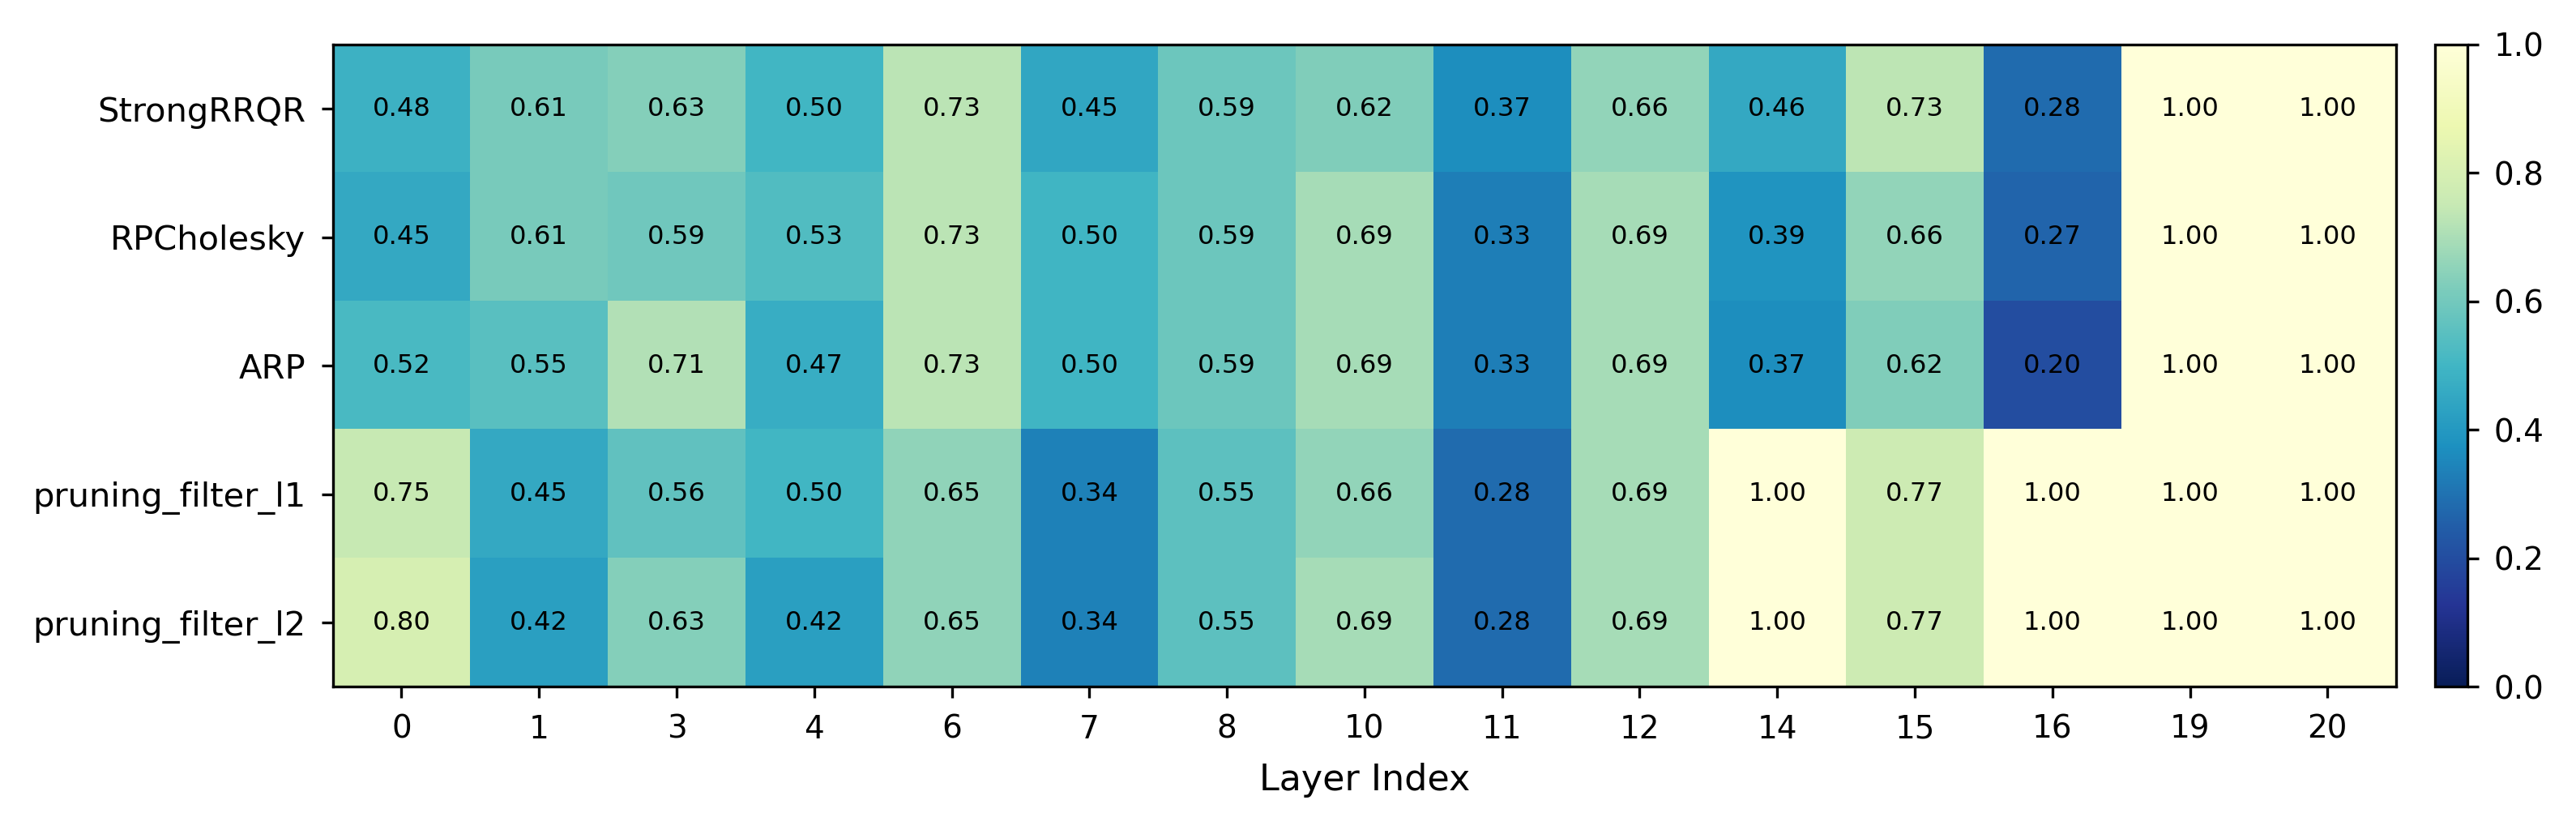

In [65]:
import importlib
import Plot as Plot
import Pruning.pruning_CSSP as pruning_CSSP

importlib.reload(Plot)
importlib.reload(pruning_CSSP)

# plot layerwise pruning results at 30% FLOPs
heatmap_data = {
    method: layerwise_results[method]["0.30"]
    for method in methods_flops
}

Plot.plot_layerwise_retention_heatmap(
    heatmap_data,
    title=None
)

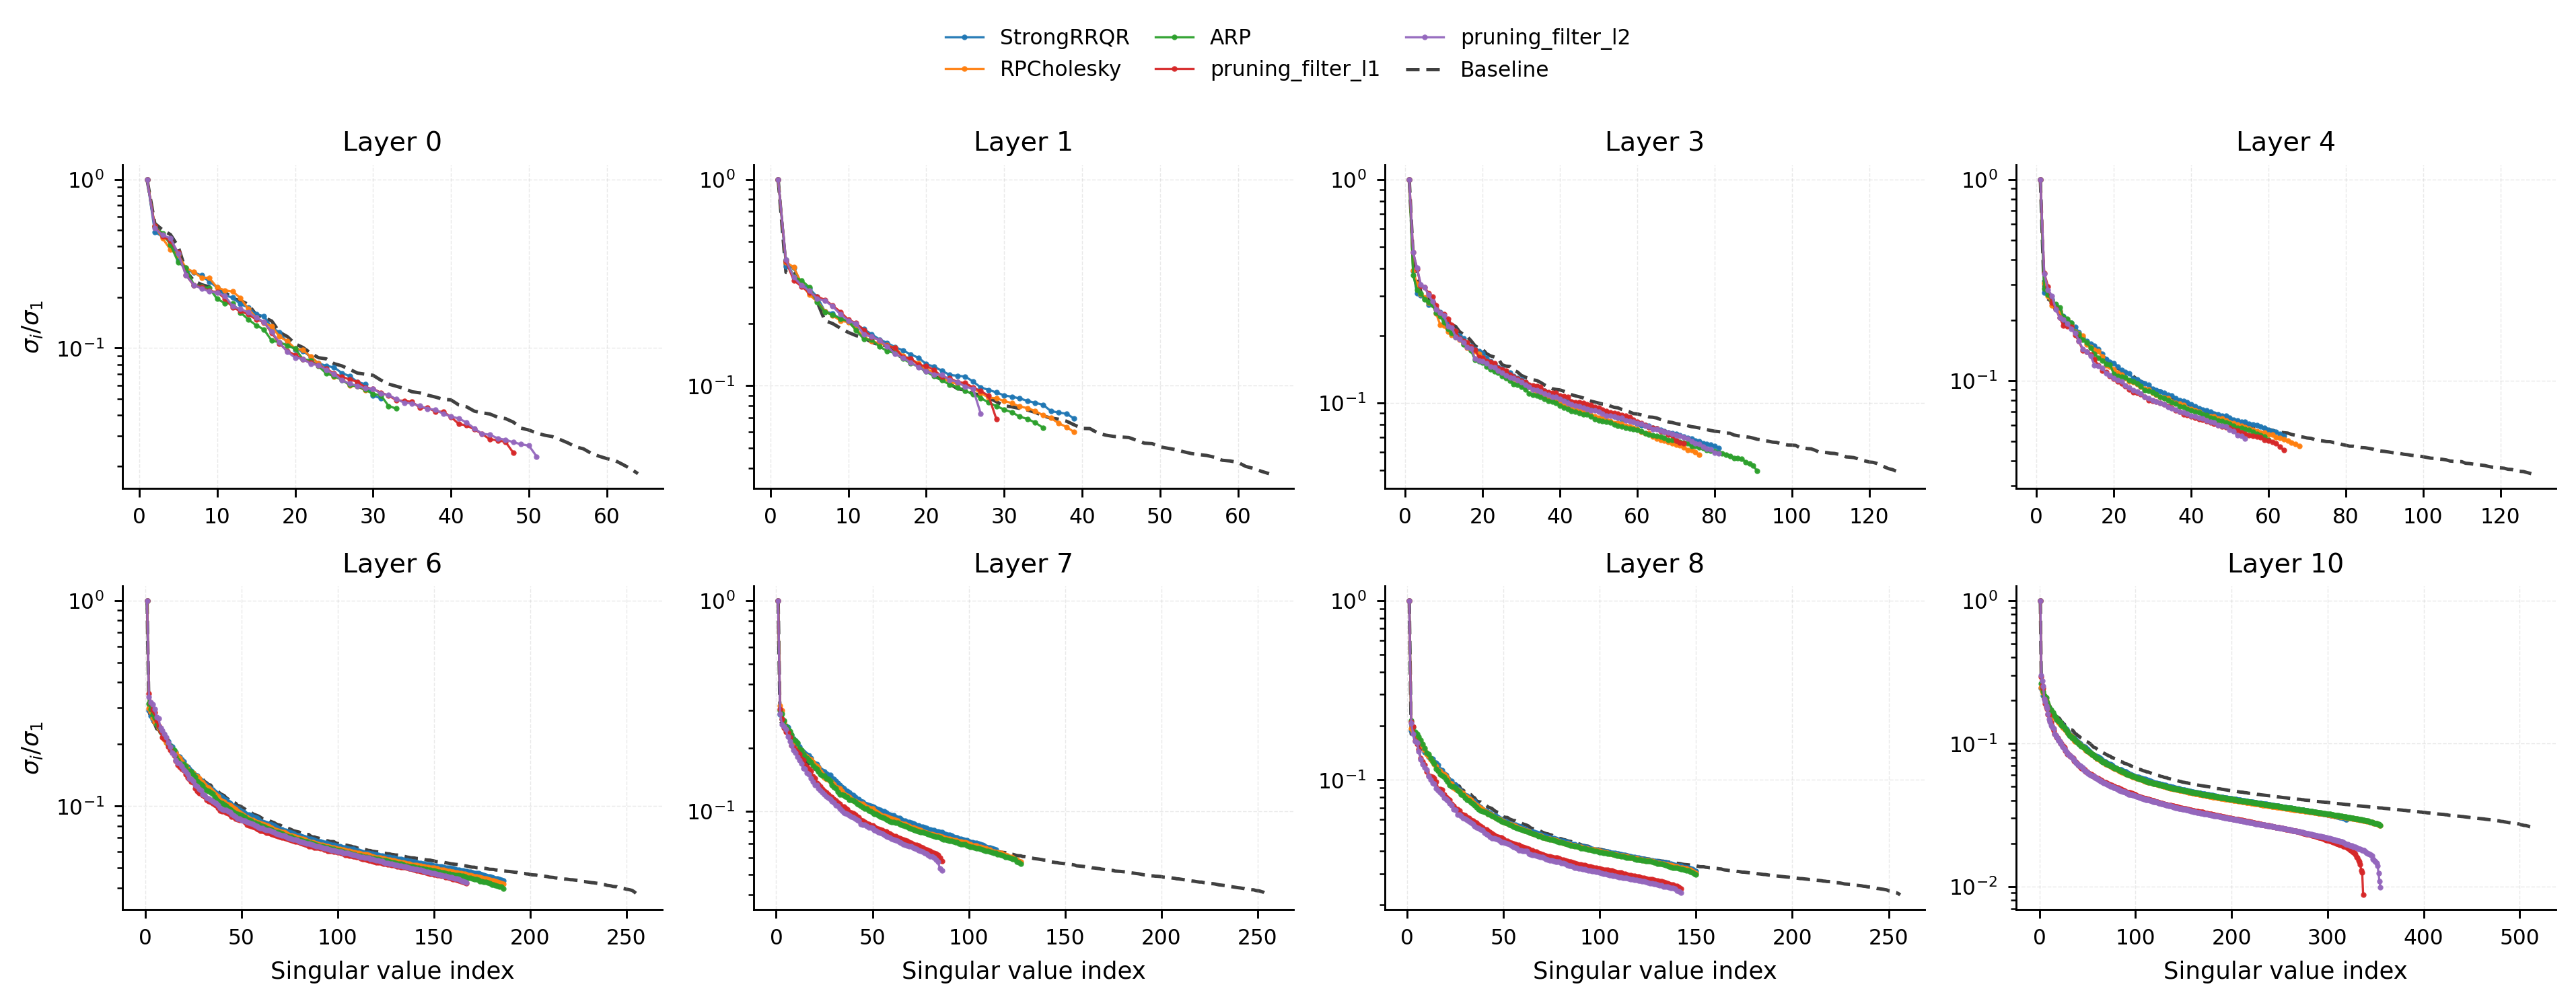

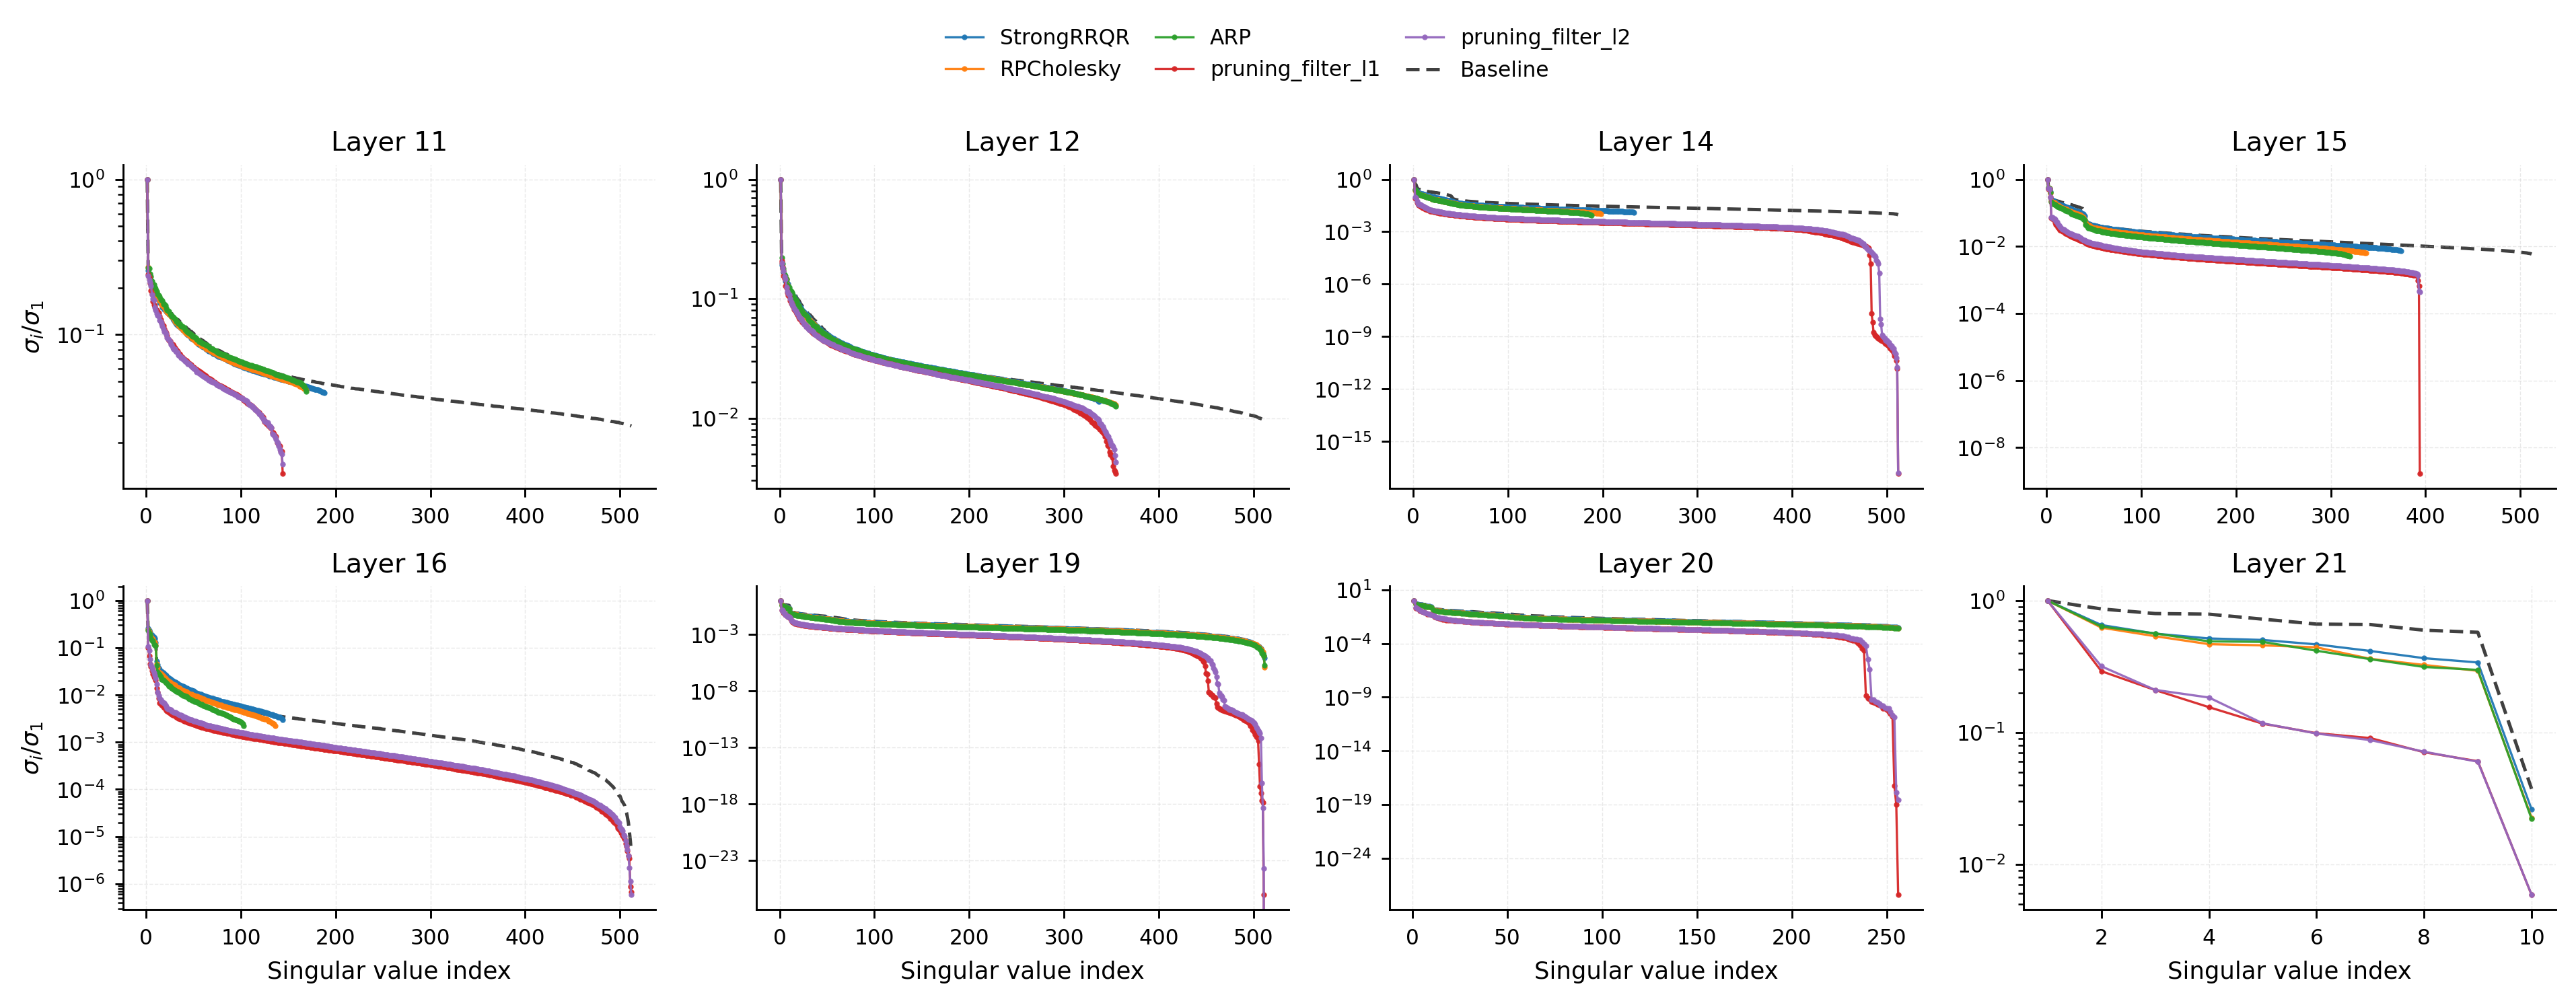

In [83]:
import importlib
import Plot as Plot
import Pruning.pruning_CSSP as pruning_CSSP

importlib.reload(Plot)
importlib.reload(pruning_CSSP)

Plot.plot_singular_values(
    pruned_models_dict,
    model3,
    params,
    X,
    layer_ls=[0, 1, 2, 3, 4, 5, 6, 7],
    rho_key="0.30",
    methods=methods_flops,
    log_scale=True,
    normalize=True,
)

Plot.plot_singular_values(
    pruned_models_dict,
    model3,
    params,
    X,
    layer_ls=[8, 9, 10, 11, 12, 14, 15, 16],
    rho_key="0.30",
    methods=methods_flops,
    log_scale=True,
    normalize=True,
)

### Part II: CSSP-Based Methods vs. Magnitude Pruning under Parameter Constraints

In [ ]:
import importlib
import Pruning.magnitude_pruning as magnitude

importlib.reload(magnitude)
rho_params = np.linspace(0.3, 0.1, 5)

methods_params = methods_CSSP + ["Magnitude"]
all_accs_params = []
all_losses_params = []
layerwise_results_params = {}
pruned_models_dict_params = {}

# Run CSSP-based pruning methods
for method in methods_CSSP:
    accs = []
    model_CSSP, accs, losses, hist, pruned_models = iterative_pruning(copy.deepcopy(model3), X, (3, 32, 32), rho_params, 0.95, method, "params", test_loader, train_loader)
    all_accs_params.append(accs)
    all_losses_params.append(losses)
    layerwise_results_params[method] = hist
    pruned_models_dict_params[method] = pruned_models

# Run magnitude pruning
magnitude_accs = []
magnitude_losses = []
with contextlib.redirect_stdout(io.StringIO()):
    model_magnitude, magnitude_accs, magnitude_losses, magnitude_hist, magnitude_models = magnitude.iterative_magnitude_pruning(
        model0=copy.deepcopy(model3),
        input_shape=(3, 32, 32),
        rho=rho_params,
        step_size=0.95,
        test_loader=test_loader,
        train_loader=train_loader,
        device=device,
        use_bn_recalibration=True,
        bn_batches=20,
    )

all_accs_params.append(magnitude_accs)
all_losses_params.append(magnitude_losses)
layerwise_results_params["Magnitude"] = magnitude_hist
pruned_models_dict_params["Magnitude"] = magnitude_models

# Save pruning results
np.savez(
    "saved model and data/params_vs_acc.npz",
    rho=rho_params,
    base_acc=base_acc,
    methods=np.array(methods_params),
    all_accs=np.array(all_accs_params),
)

np.savez(
    "saved model and data/params_vs_loss.npz",
    rho=rho_params,
    base_loss=base_loss,
    methods=np.array(methods_params),
    all_losses=np.array(all_losses_params),
)

-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.30
Current ratio: 0.2970, Accuracy: 0.8806, Current FLOPs ratio: 0.7061
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.25
Current ratio: 0.2473, Accuracy: 0.8702, Current FLOPs ratio: 0.6631
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.20
Current ratio: 0.1989, Accuracy: 0.8489, Current FLOPs ratio: 0.5927
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.15
Current ratio: 0.1485, Accuracy: 0.8195, Current FLOPs ratio: 0.5195
-------Begin pruning-------
Method: StrongRRQR	Target ratio: 0.10
Current ratio: 0.0994, Accuracy: 0.7630, Current FLOPs ratio: 0.4231
Params after pruning: 15121226 -> 1503166
-------Begin pruning-------
Method: RPCholesky	Target ratio: 0.30
Current ratio: 0.2988, Accuracy: 0.8749, Current FLOPs ratio: 0.7192
-------Begin pruning-------
Method: RPCholesky	Target ratio: 0.25
Current ratio: 0.2498, Accuracy: 0.8660, Current FLOPs ratio: 0.6715
-------Begin 

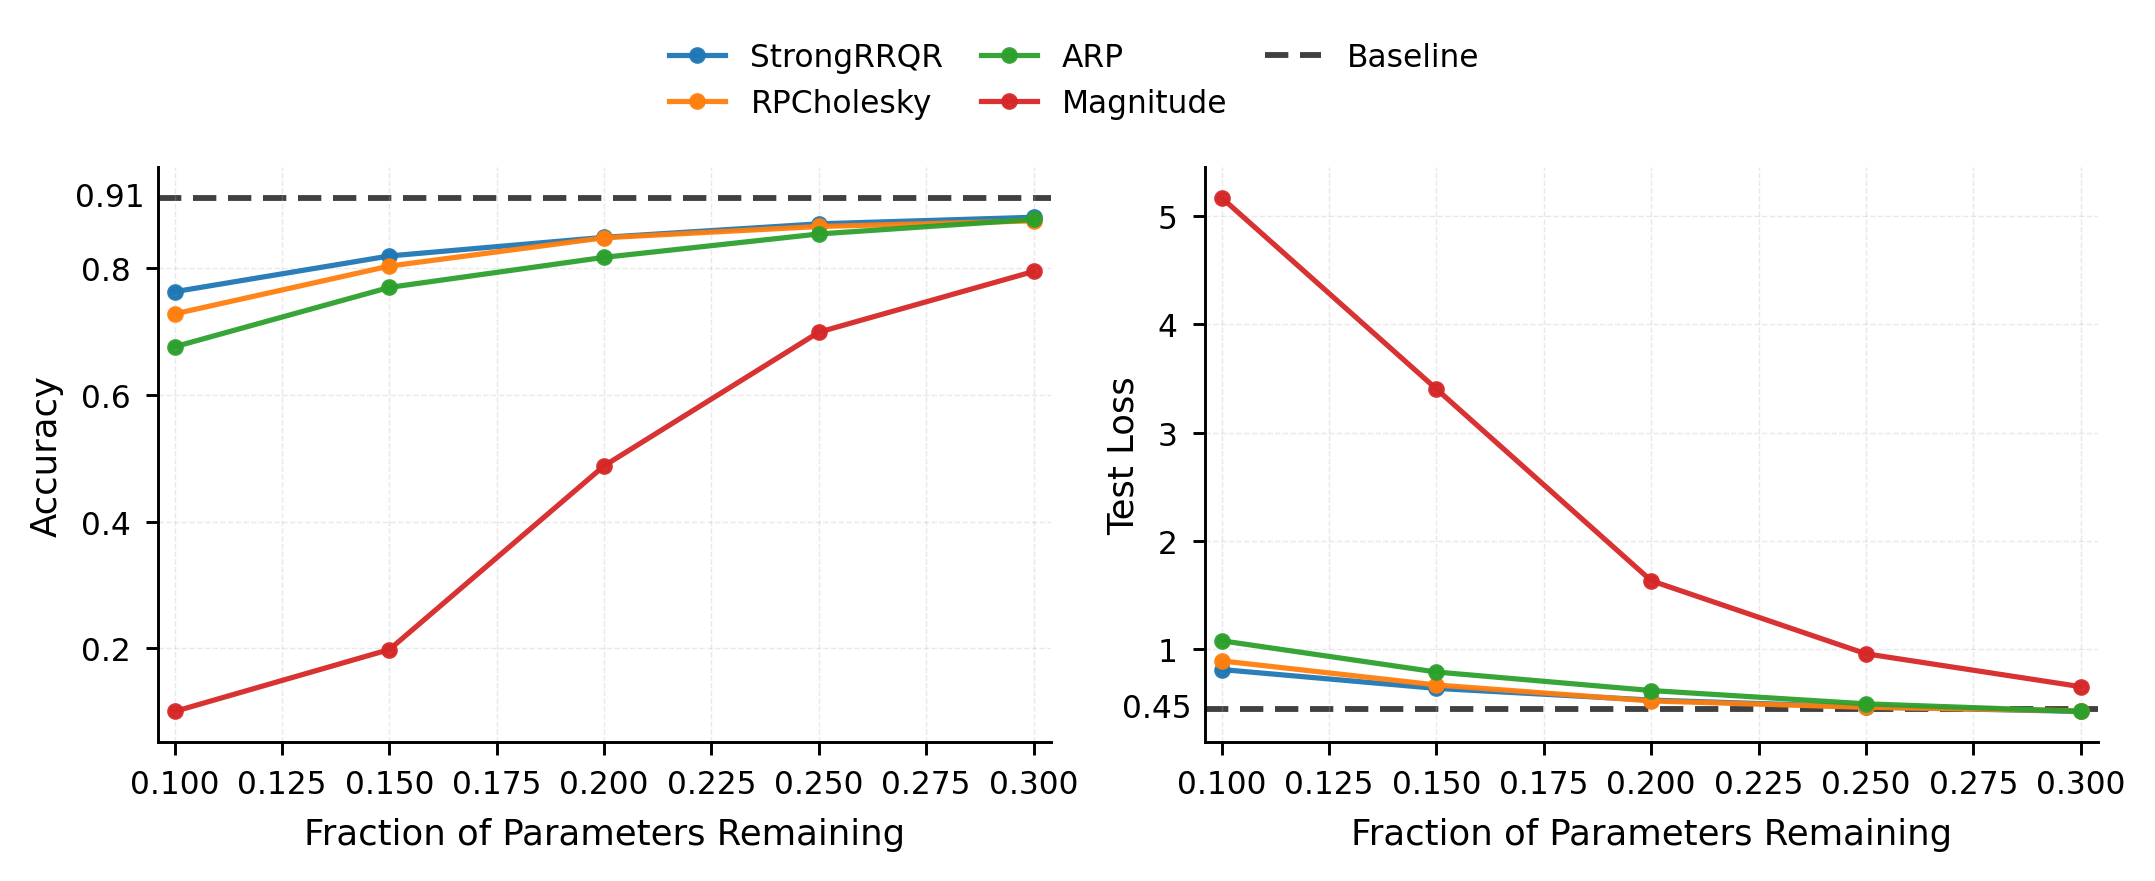

In [69]:
import importlib
import Plot as Plot

importlib.reload(Plot)

# Plot pruning curves
Plot.plot_pruning_curve(
    base_acc,
    rho_params,
    all_accs_params,
    methods_params,
    "params",
    "Accuracy",
    title=None,
    base_loss=base_loss,
    losses=all_losses_params,
)

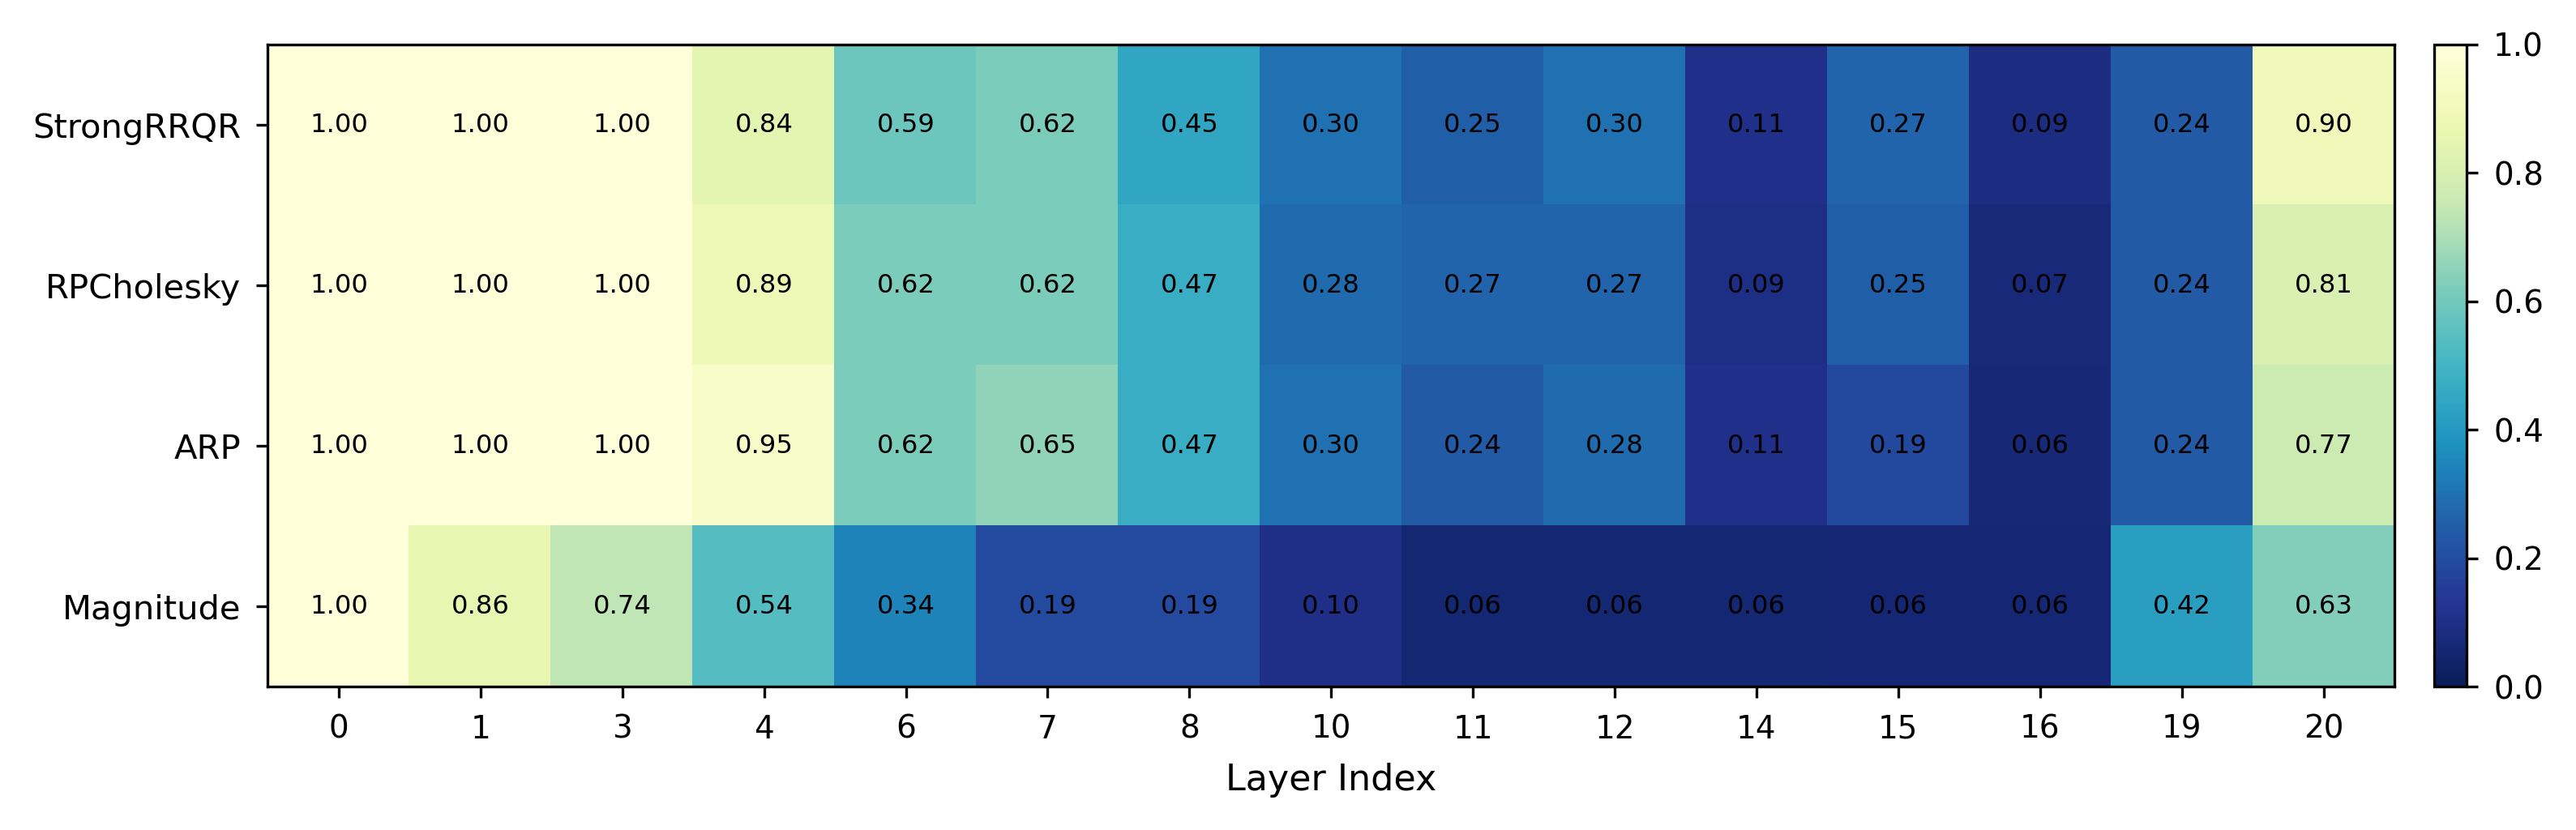

In [86]:
import importlib
import Plot as Plot

importlib.reload(Plot)

heatmap_data_params = {
    method: layerwise_results_params[method]["0.10"]
    for method in methods_params
}
Plot.plot_layerwise_retention_heatmap(
    heatmap_data_params,
    title=None
)

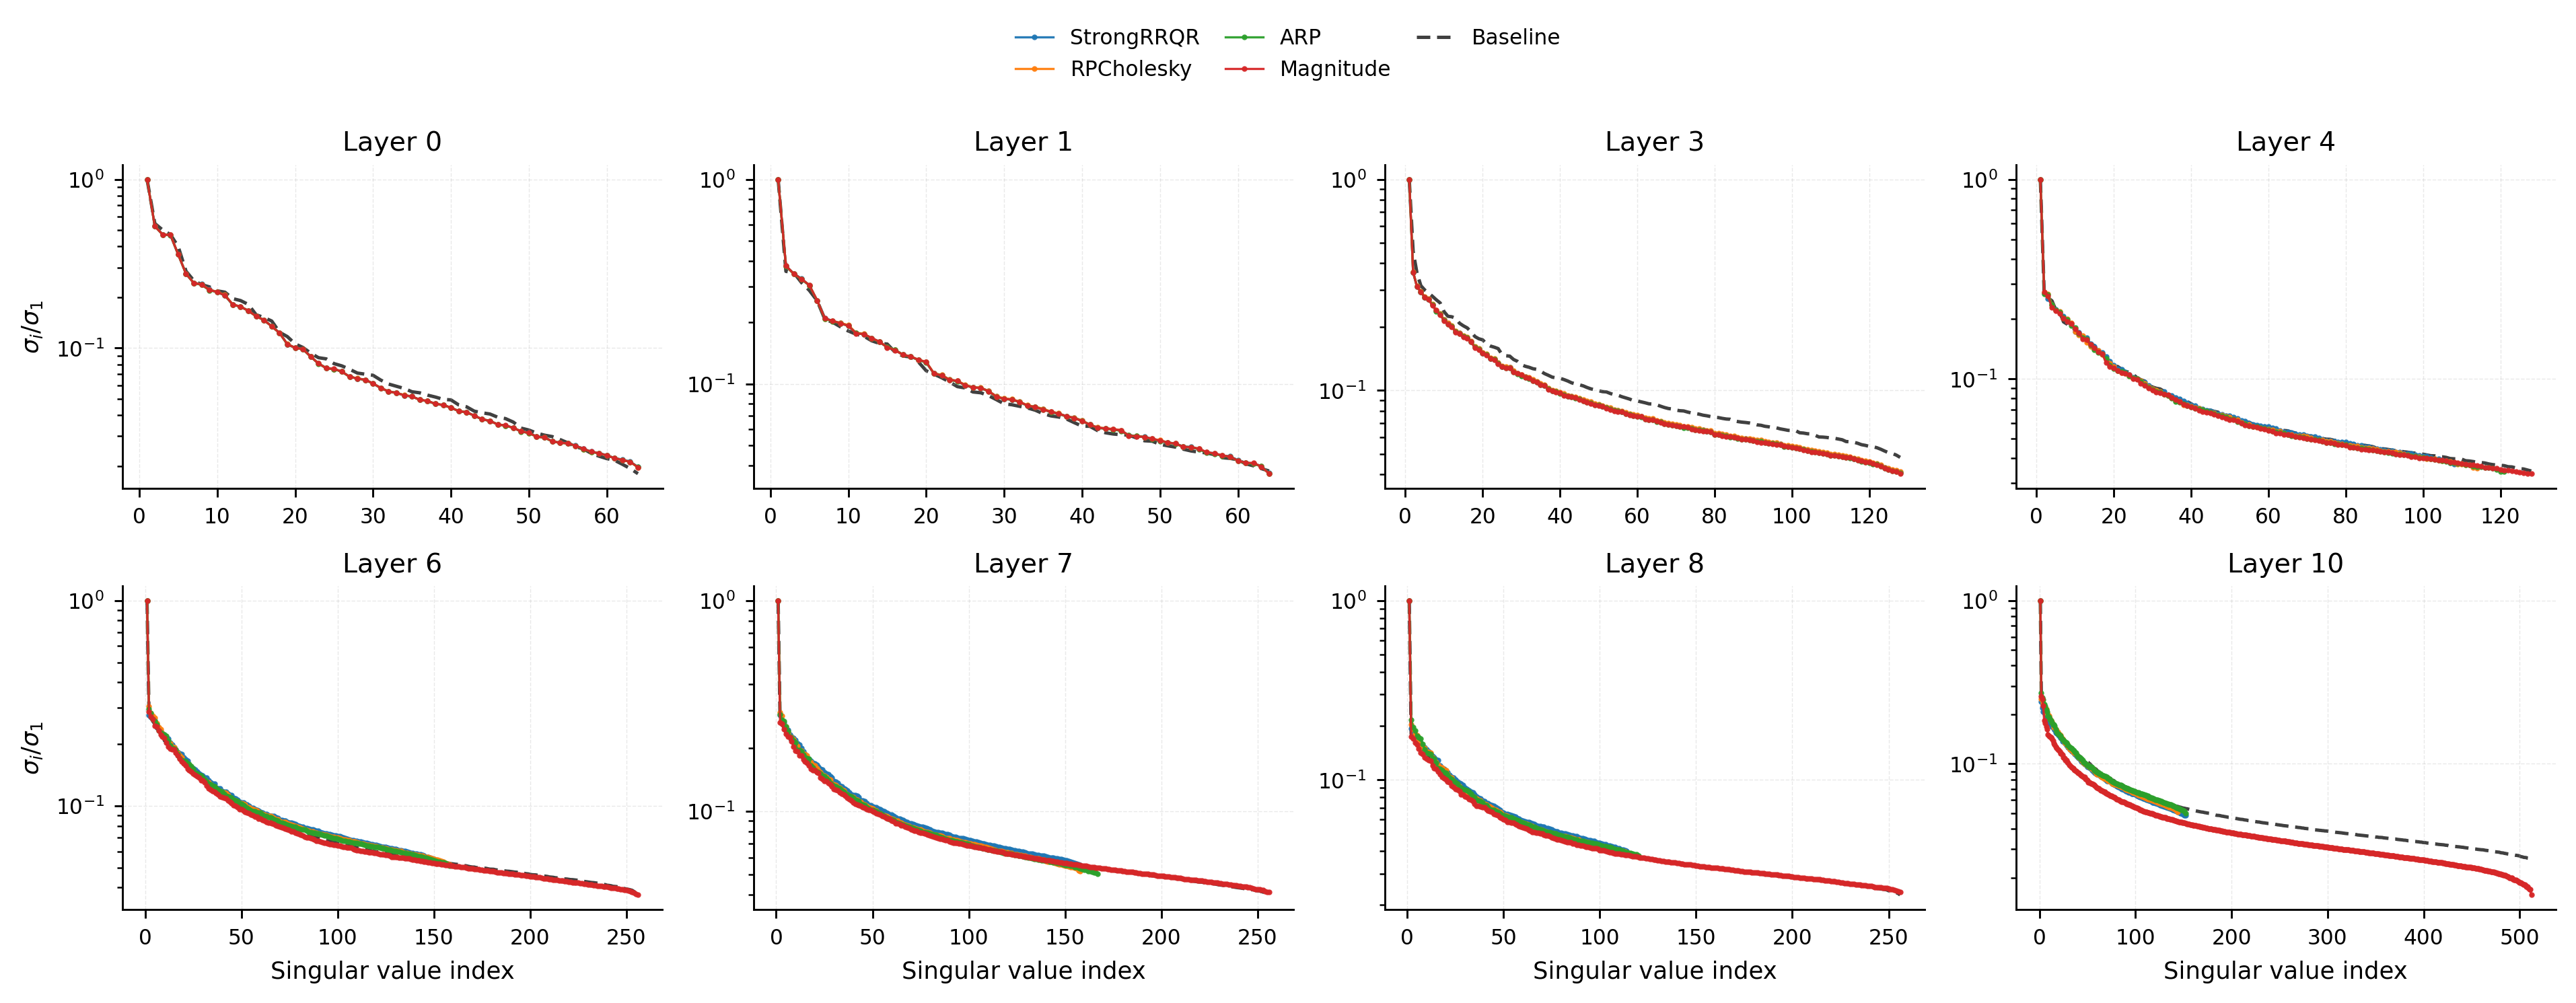

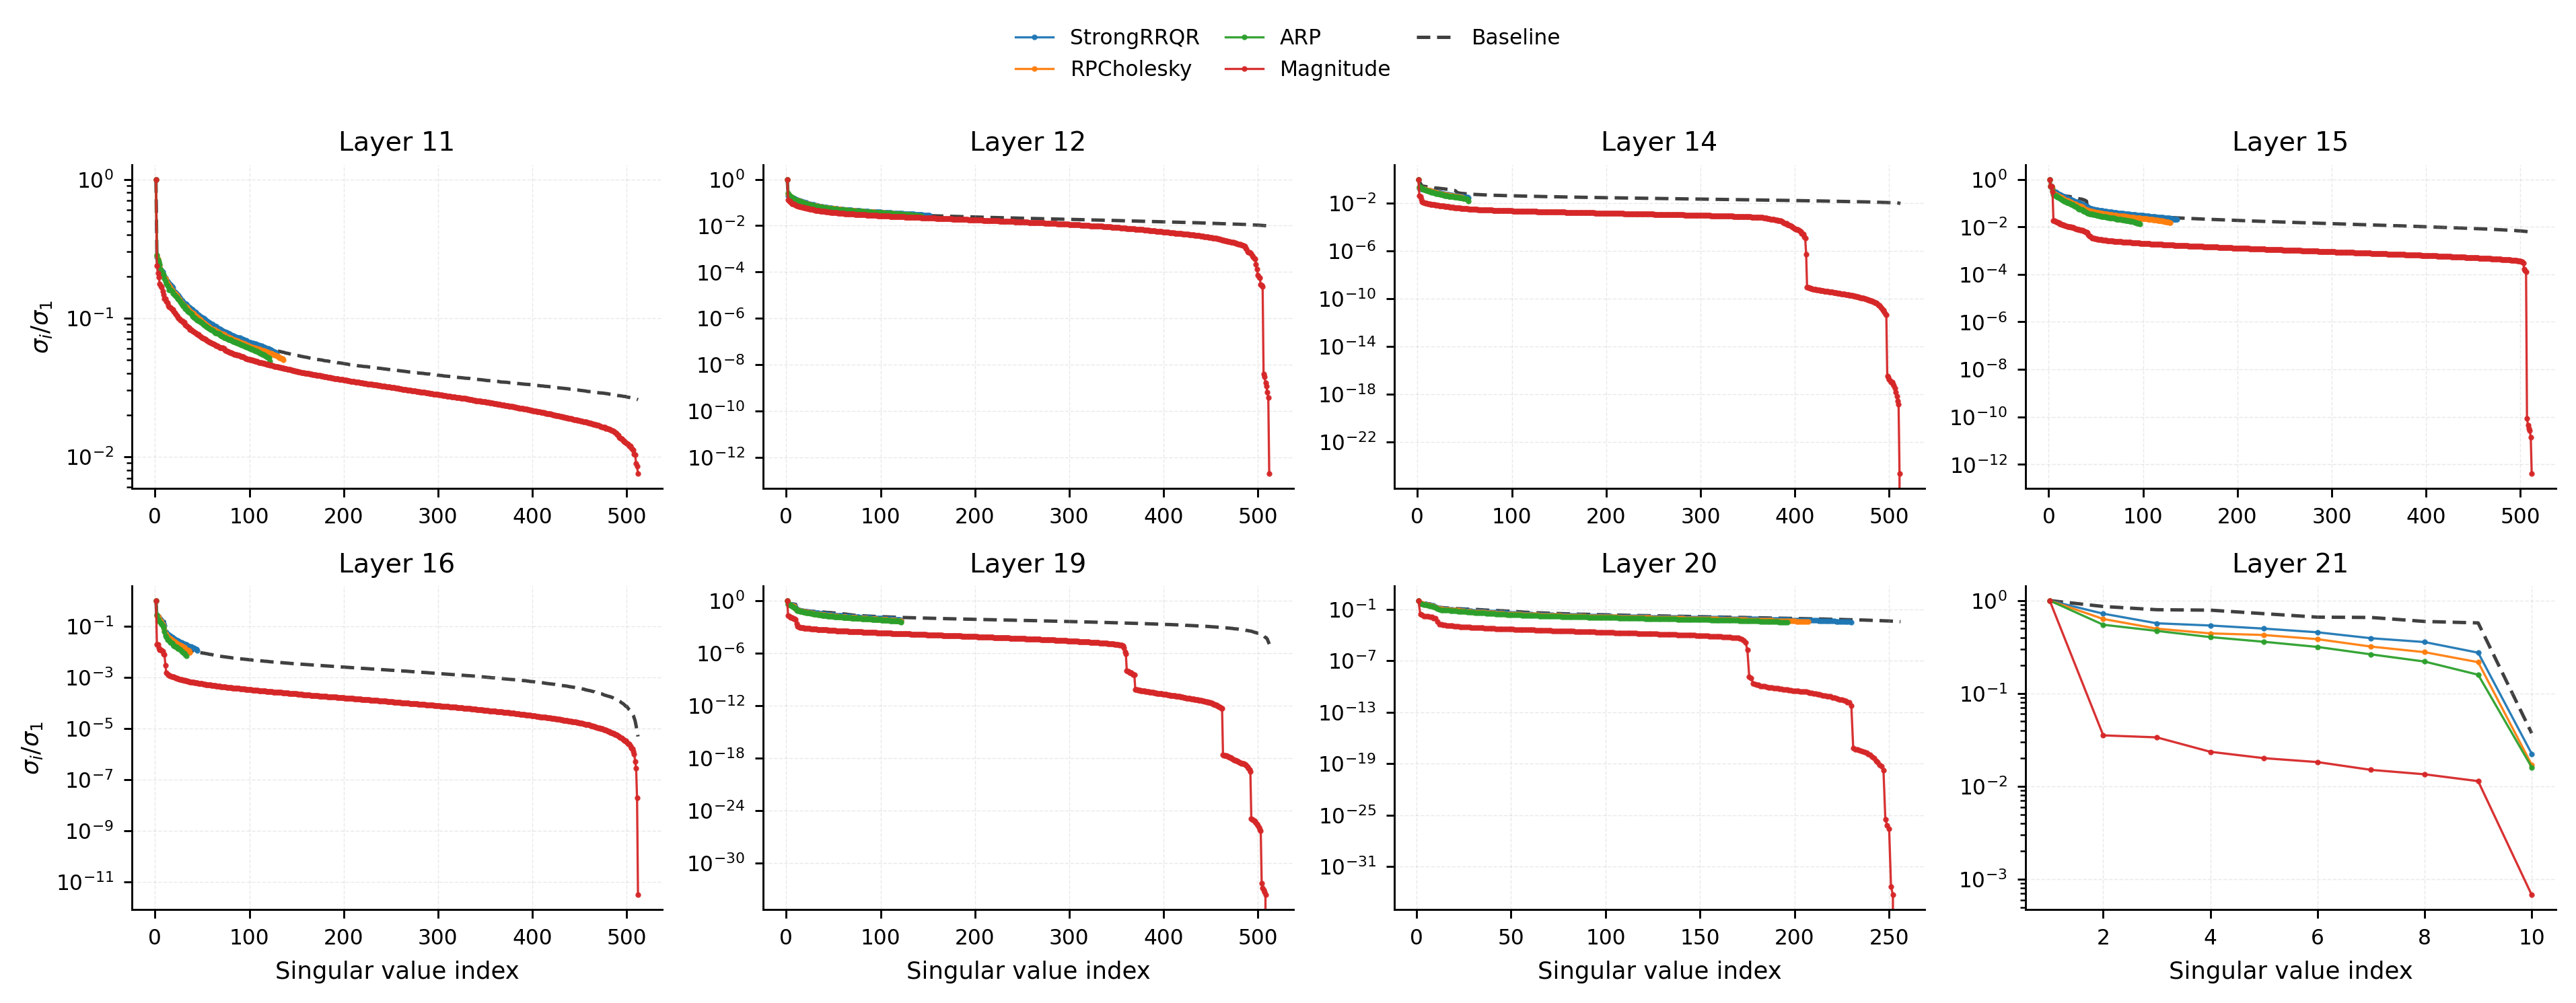

In [87]:
import importlib
import Plot as Plot
import Pruning.pruning_CSSP as pruning_CSSP

importlib.reload(Plot)
importlib.reload(pruning_CSSP)

Plot.plot_singular_values(
    pruned_models_dict_params,
    model3,
    params,
    X,
    layer_ls=[0, 1, 2, 3, 4, 5, 6, 7],
    rho_key="0.10",
    methods=methods_params,
    log_scale=True,
    normalize=True,
)

Plot.plot_singular_values(
    pruned_models_dict_params,
    model3,
    params,
    X,
    layer_ls=[8, 9, 10, 11, 12, 14, 15, 16],
    rho_key="0.10",
    methods=methods_params,
    log_scale=True,
    normalize=True,
)